## Data Visualization CA1
## Matthew Riddell - D00245674

### Data Exploration Notebook

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

import scipy

In [32]:
# Read each CSV
data_2023 = pd.read_csv("C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Data Visualisation and Insight/CAs/CA1/Data-Vis-CA1/Matthew/Datasets/season_2223.csv")
data_2024 = pd.read_csv("C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Data Visualisation and Insight/CAs/CA1/Data-Vis-CA1/Matthew/Datasets/season_2324.csv")
data_2025 = pd.read_csv("C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Data Visualisation and Insight/CAs/CA1/Data-Vis-CA1/Matthew/Datasets/season_2425.csv")

In [33]:
data_2023["Season"] = "2020 / 2021"
data_2024["Season"] = "2021 / 2022"
data_2025["Season"] = "2022 / 2023"

In [34]:
# Combine datasets
season_data = pd.concat([data_2023, data_2024, data_2025], ignore_index=True)

#### Display Head

In [35]:
season_data.head(10)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,05/08/22,Crystal Palace,Arsenal,0,2,A,0,1,A,A Taylor,...,2,16,11,3,5,1,2,0,0,2020 / 2021
1,06/08/22,Fulham,Liverpool,2,2,D,1,0,H,A Madley,...,4,7,9,4,4,2,0,0,0,2020 / 2021
2,06/08/22,Bournemouth,Aston Villa,2,0,H,1,0,H,P Bankes,...,2,18,16,5,5,3,3,0,0,2020 / 2021
3,06/08/22,Leeds,Wolves,2,1,H,1,1,D,R Jones,...,6,13,9,6,4,2,0,0,0,2020 / 2021
4,06/08/22,Newcastle,Nott'm Forest,2,0,H,0,0,D,S Hooper,...,0,9,14,11,1,0,3,0,0,2020 / 2021
5,06/08/22,Tottenham,Southampton,4,1,H,2,1,H,A Marriner,...,2,11,6,10,2,3,0,0,0,2020 / 2021
6,06/08/22,Everton,Chelsea,0,1,A,0,1,A,C Pawson,...,6,14,11,4,16,3,2,0,0,2020 / 2021
7,07/08/22,Leicester,Brentford,2,2,D,1,0,H,J Gillett,...,3,6,5,5,6,0,0,0,0,2020 / 2021
8,07/08/22,Man United,Brighton,1,2,A,0,2,A,P Tierney,...,4,7,12,6,2,4,1,0,0,2020 / 2021
9,07/08/22,West Ham,Man City,0,2,A,0,1,A,M Oliver,...,2,8,4,1,4,0,1,0,0,2020 / 2021


#### Data Info

In [36]:
season_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      1140 non-null   object
 1   HomeTeam  1140 non-null   object
 2   AwayTeam  1140 non-null   object
 3   FTHG      1140 non-null   int64 
 4   FTAG      1140 non-null   int64 
 5   FTR       1140 non-null   object
 6   HTHG      1140 non-null   int64 
 7   HTAG      1140 non-null   int64 
 8   HTR       1140 non-null   object
 9   Referee   1140 non-null   object
 10  HS        1140 non-null   int64 
 11  AS        1140 non-null   int64 
 12  HST       1140 non-null   int64 
 13  AST       1140 non-null   int64 
 14  HF        1140 non-null   int64 
 15  AF        1140 non-null   int64 
 16  HC        1140 non-null   int64 
 17  AC        1140 non-null   int64 
 18  HY        1140 non-null   int64 
 19  AY        1140 non-null   int64 
 20  HR        1140 non-null   int64 
 21  AR        1140

#### Data Shape

In [37]:
print("Shape:", season_data.shape)

Shape: (1140, 23)


#### Renaming Columns

In [59]:
season_data = season_data.rename(columns={
    'Date': 'Match Date',
    'HomeTeam': 'Home Team',
    'AwayTeam': 'Away Team',
    'FTHG': 'Full Time Home Goals',
    'FTAG': 'Full Time Away Goals',
    'FTR': 'Full Time Result',
    'HTHG': 'Half Time Home Goals',
    'HTAG': 'Half Time Away Goals',
    'HTR': 'Half Time Result',
    'Referee': 'Match Referee',
    'HS': 'Home Team Shots',
    'AS': 'Away Team Shots',
    'HST': 'Home Team Shots on Target',
    'AST': 'Away Team Shots on Target',
    'HF': 'Home Team Fouls',
    'AF': 'Away Team Fouls',
    'HC': 'Home Team Corners',
    'AC': 'Away Team Corners',
    'HY': 'Home Team Yellow Cards',
    'AY': 'Away Team Yellow Cards',
    'HR': 'Home Team Red Cards',
    'AR': 'Away Team Red Cards',
    'Season': 'Season'
})

#### Summary Statistics

In [58]:
# Summary statistics of each variable
season_data.describe()

,Full Time Home Goals,Full Time Away Goals,Half Time Home Goals,Half Time Away Goals,Home Team Shots,Away Team Shots,Home Team Shots on Target,Away Team Shots on Target,Home Team Fouls,Away Team Fouls,Home Team Corners,Away Team Corners,Home Team Yellow Cards,Away Team Yellow Cards,Home Team Red Cards,Away Team Red Cards
count,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000
mean,1.649123,1.372807,0.748246,0.600000,14.369298,11.885965,5.059649,4.197368,10.710526,11.185088,5.728947,4.685088,1.828947,2.107895,0.061404,0.058772
std,1.359663,1.221895,0.875351,0.800351,5.867690,5.289277,2.640926,2.377941,3.462641,3.553176,3.170768,2.921860,1.351241,1.399150,0.250901,0.239003
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,8.000000,3.000000,3.000000,8.000000,9.000000,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,14.000000,11.000000,5.000000,4.000000,10.000000,11.000000,5.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,18.000000,15.000000,7.000000,5.000000,13.000000,14.000000,8.000000,6.000000,3.000000,3.000000,0.000000,0.000000
max,9.000000,8.000000,5.000000,5.000000,36.000000,37.000000,16.000000,15.000000,23.000000,24.000000,17.000000,19.000000,7.000000,8.000000,2.000000,2.000000


#### Pairplots of numerical columns

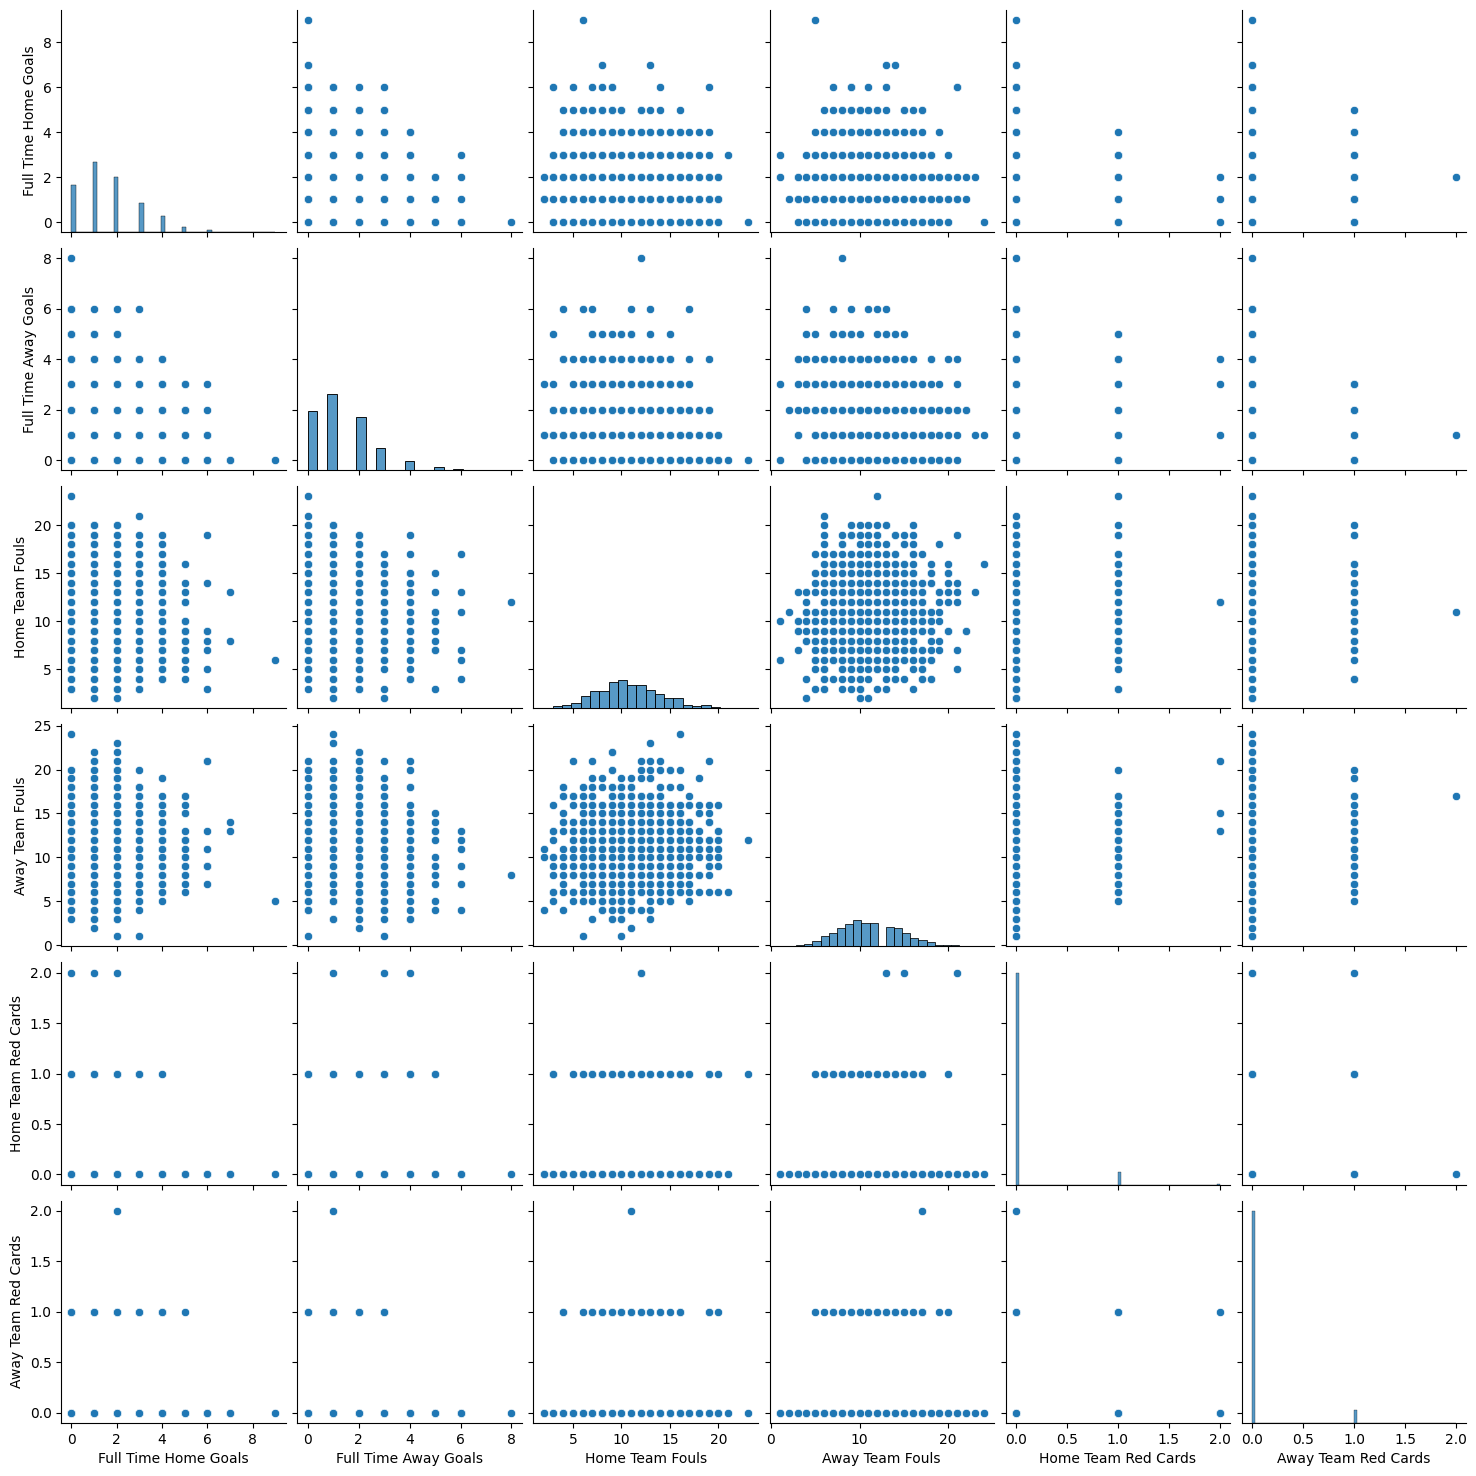

In [60]:
num_cols = ['Full Time Home Goals',
       'Full Time Away Goals',
       'Home Team Fouls', 'Away Team Fouls',
       'Home Team Red Cards', 'Away Team Red Cards']

sns.pairplot(season_data[num_cols])
plt.show()

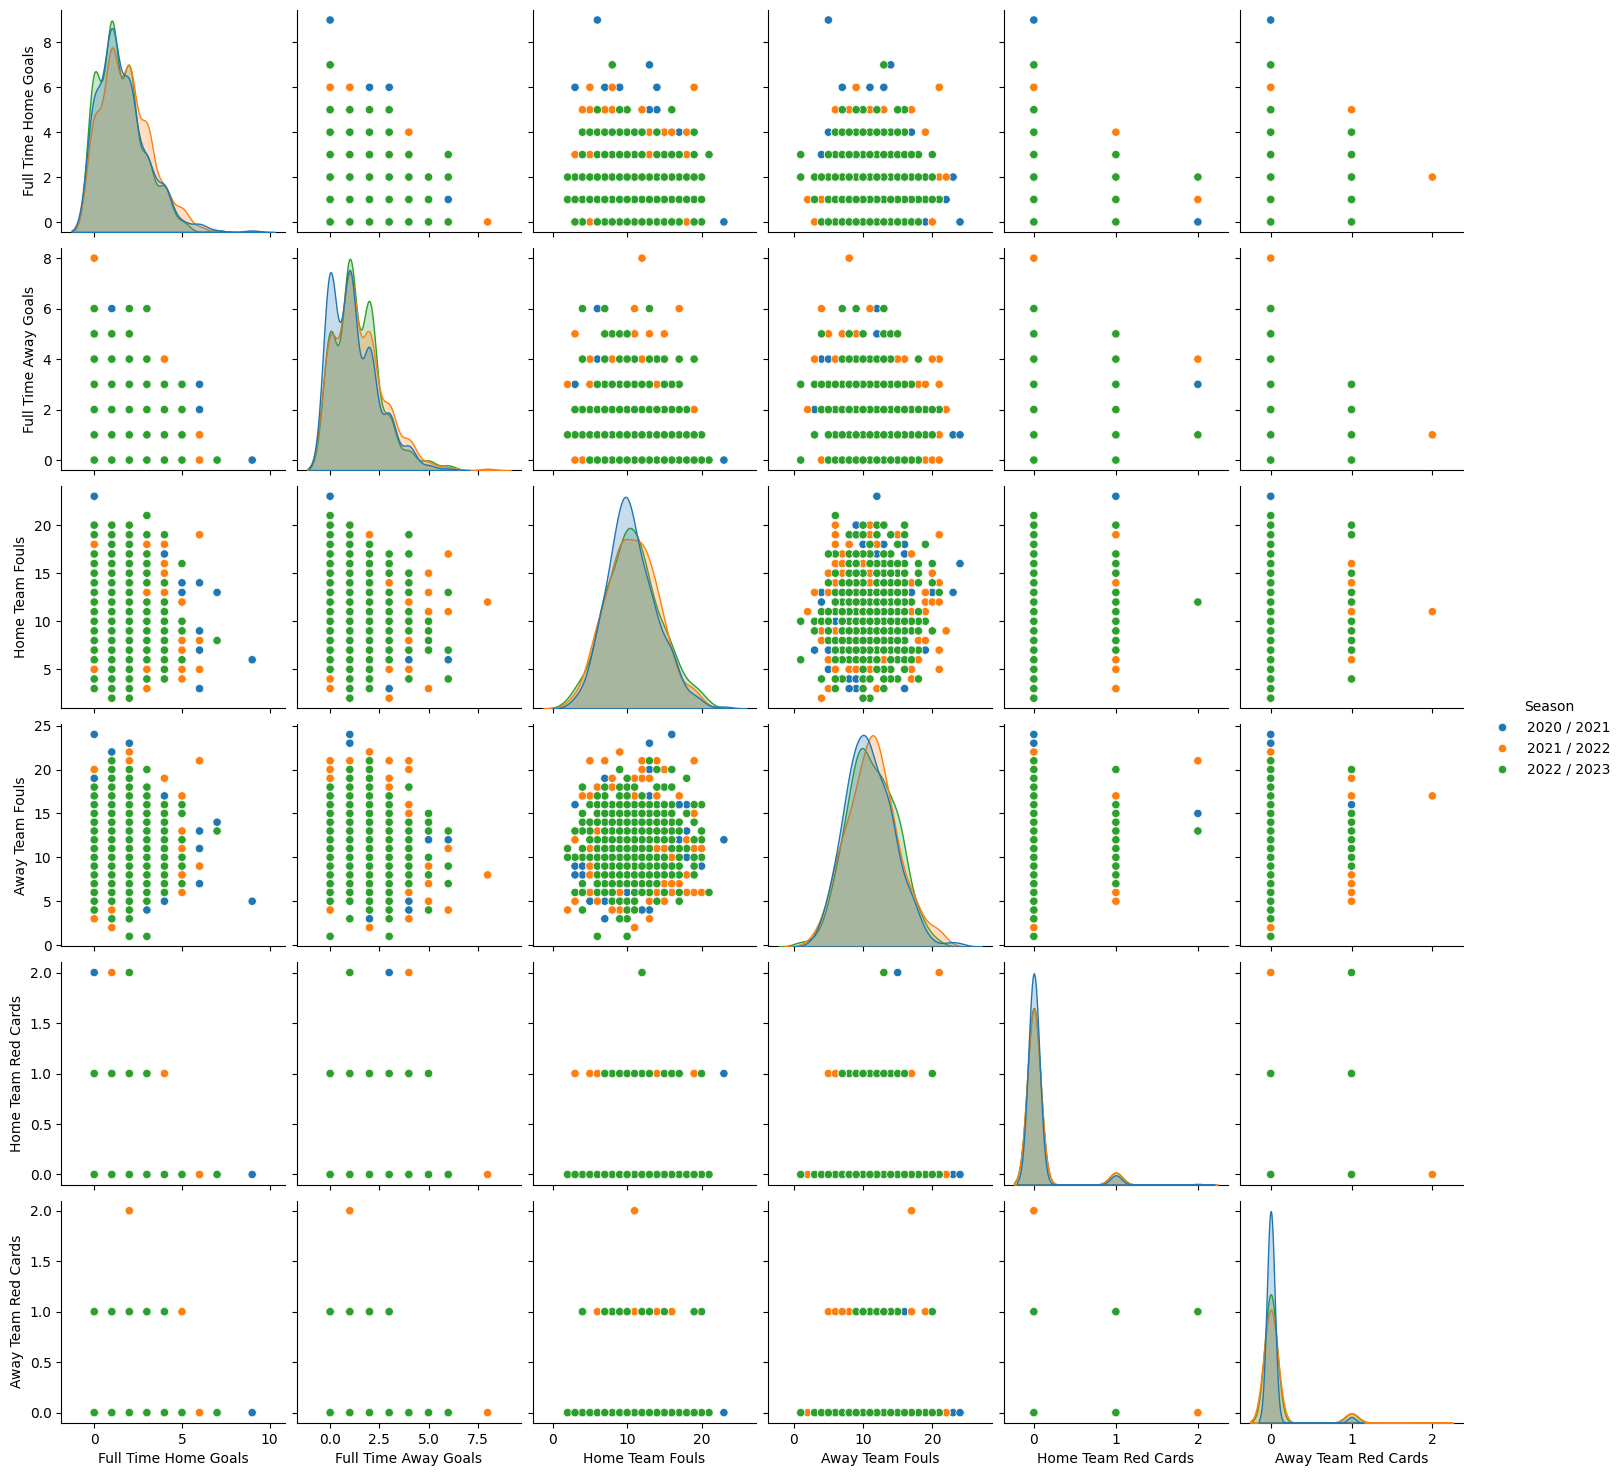

In [41]:
### colour coding based on Season

sns.pairplot(season_data[num_cols + ['Season']], hue='Season')
plt.show()

### Barplot of fulltime home goals 

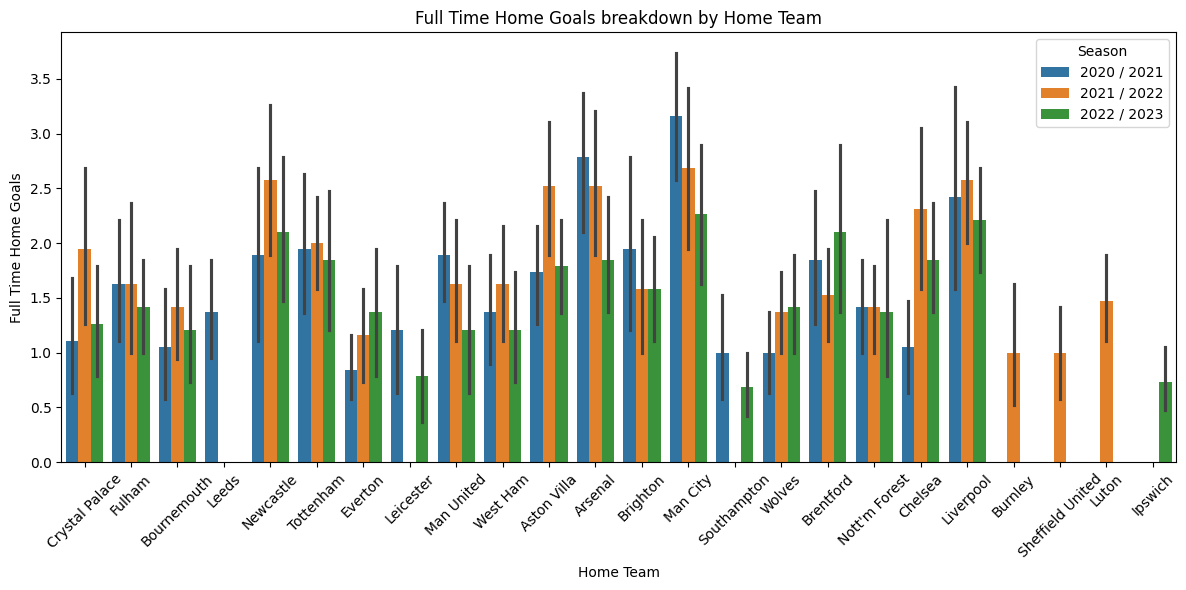

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=season_data,
    x='Home Team',
    y='Full Time Home Goals',
    hue='Season'
)

plt.title('Full Time Home Goals breakdown by Home Team')
plt.xlabel('Home Team')
plt.ylabel('Full Time Home Goals')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### Barplot of fulltime away goals

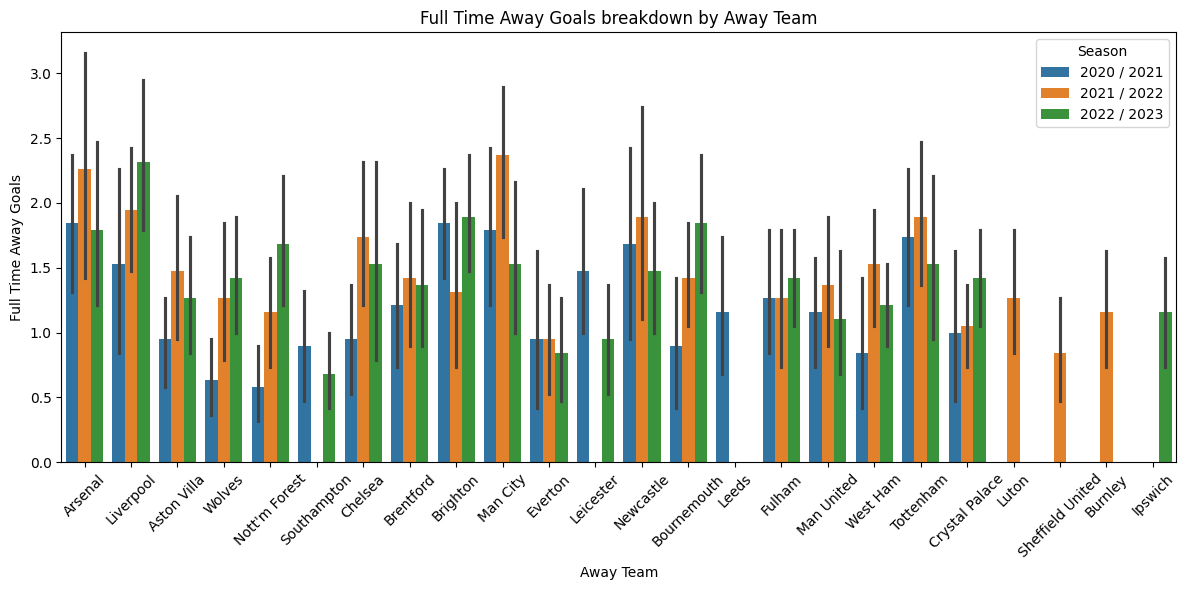

In [46]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=season_data,
    x='Away Team',
    y='Full Time Away Goals',
    hue='Season'
)

plt.title('Full Time Away Goals breakdown by Away Team')
plt.xlabel('Away Team')
plt.ylabel('Full Time Away Goals')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Boxplots of fulltime home goals by home team

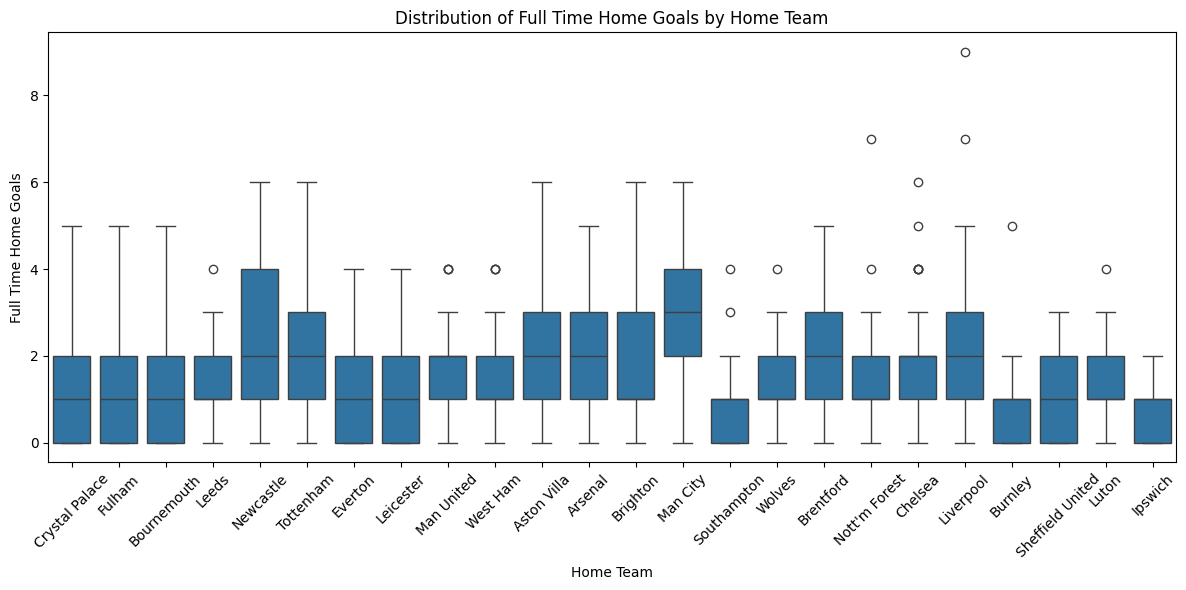

In [47]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=season_data,
    x='Home Team',
    y='Full Time Home Goals'
)

plt.title('Distribution of Full Time Home Goals by Home Team')
plt.xlabel('Home Team')
plt.ylabel('Full Time Home Goals')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Boxplots of fulltime away goals by away team

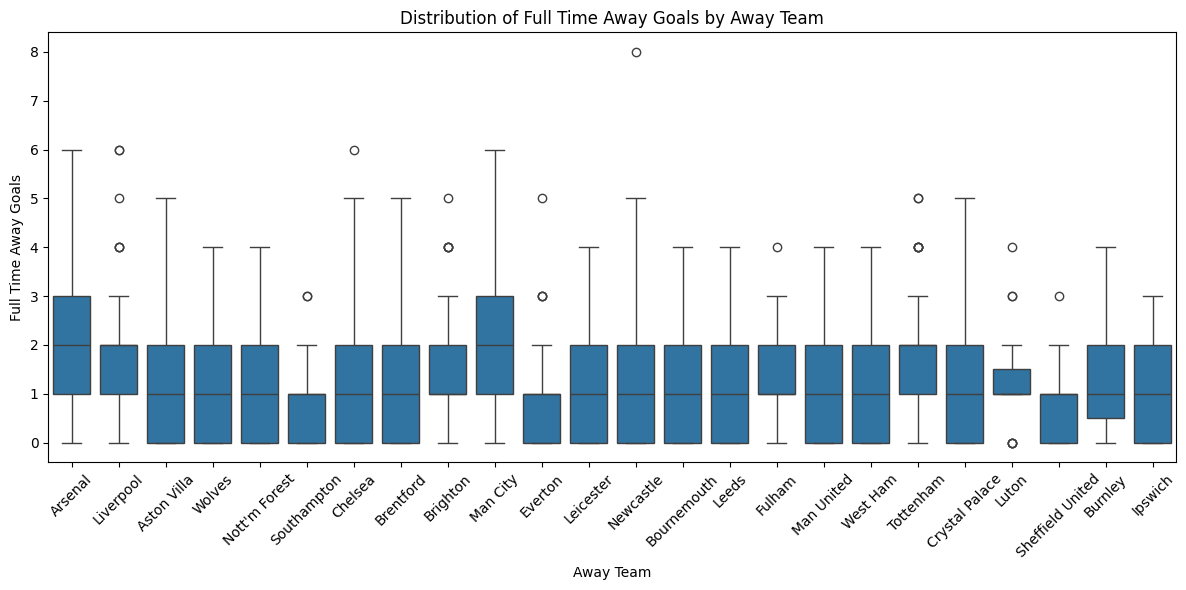

In [48]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=season_data,
    x='Away Team',
    y='Full Time Away Goals'
)

plt.title('Distribution of Full Time Away Goals by Away Team')
plt.xlabel('Away Team')
plt.ylabel('Full Time Away Goals')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Creating separate dataframes for home and away teams 

In [61]:
home = season_data[['Home Team','Full Time Home Goals']]
home.columns = ['Team','Goals']

away = season_data[['Away Team','Full Time Away Goals']]
away.columns = ['Team','Goals']

all_goals = pd.concat([home, away])

### Showing total Goals per team

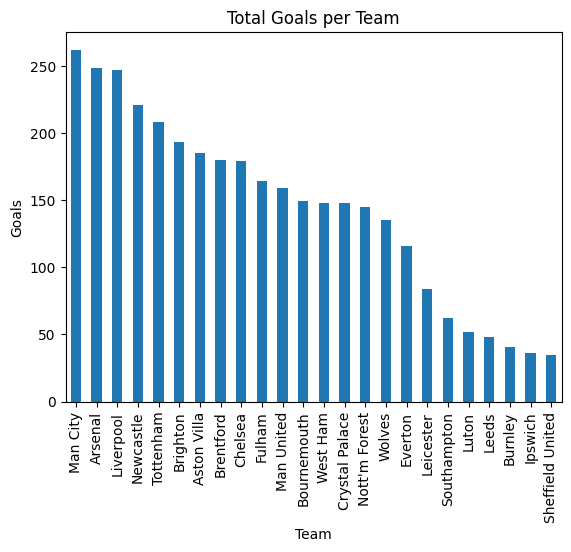

In [62]:
goals_per_team = all_goals.groupby('Team')['Goals'].sum().sort_values(ascending=False)

plt.figure()
goals_per_team.plot(kind='bar')
plt.title("Total Goals per Team")
plt.ylabel("Goals")
plt.show()

#### Showing overall match outcomes

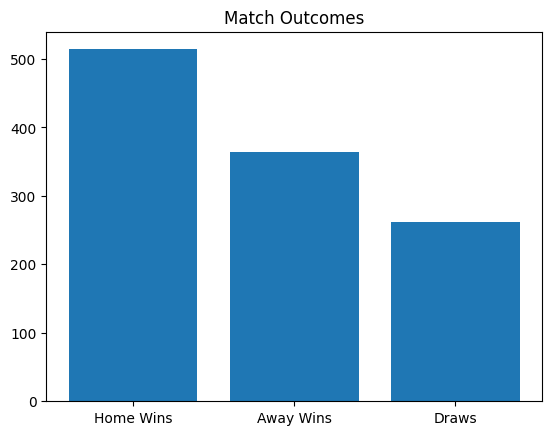

In [63]:
home_wins = season_data[season_data['Full Time Result'] == 'H'].shape[0]
away_wins = season_data[season_data['Full Time Result'] == 'A'].shape[0]
draws = season_data[season_data['Full Time Result'] == 'D'].shape[0]

plt.figure()
plt.bar(['Home Wins','Away Wins','Draws'], [home_wins, away_wins, draws])
plt.title("Match Outcomes")
plt.show()